Acá lo que hacemos es preparar los datos para la red neuronal: vamos a limpiar, convertir texto a números, dividir en entrenamiento y prueba, y escalar.

In [11]:
# Cargamos y limpiamos #
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# TotalCharges: el espacio en blanco pasa a ser un valor nulo y la columna se convierte a número #
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = df["TotalCharges"].apply(pd.to_numeric)

# Eliminamos los 11 registros con TotalCharges nulo (clientes con tenure = 0, ver notebook 01) #
df.dropna(inplace=True)

# customerID es solo un código, no sirve para predecir #
df = df.drop(columns="customerID")

# Churn en número: 1 = se fue, 0 = se quedó #
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print(df.shape)

(7032, 20)


In [12]:
# vamos a unir "No internet service" y "No phone service" #
df = df.replace({"No internet service": "No", "No phone service": "No"})

In [13]:
# Feature engineering: cuántos servicios extra tiene cada cliente (en el notebook 01 se ve que la tasa de churn baja conforme el cliente tiene más servicios) #
servicios = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
             "TechSupport", "StreamingTV", "StreamingMovies"]
df["num_servicios"] = (df[servicios] == "Yes").sum(axis=1)

In [14]:
# Vamos a convertir texto a numero (get_dummies) #
df = pd.get_dummies(df, drop_first=True)

print(df.shape)
df.head()

(7032, 25)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,num_servicios,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,2,True,False,False,True,...,True,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,2,True,False,False,True,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,3,True,False,False,False,...,True,True,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,0,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False


Correlación de todas las variables con Churn

Ahora que todas las variables están en número, vemos cuáles tienen mayor correlación con la variable objetivo.

In [15]:
df.corr()['Churn'].sort_values()

tenure                                  -0.354049
Contract_Two year                       -0.301552
InternetService_No                      -0.227578
TotalCharges                            -0.199484
Contract_One year                       -0.178225
OnlineSecurity_Yes                      -0.171270
TechSupport_Yes                         -0.164716
Dependents_Yes                          -0.163128
Partner_Yes                             -0.149982
PaymentMethod_Credit card (automatic)   -0.134687
PaymentMethod_Mailed check              -0.090773
num_servicios                           -0.087882
OnlineBackup_Yes                        -0.082307
DeviceProtection_Yes                    -0.066193
gender_Male                             -0.008545
PhoneService_Yes                         0.011691
MultipleLines_Yes                        0.040033
StreamingMovies_Yes                      0.060860
StreamingTV_Yes                          0.063254
SeniorCitizen                            0.150541


<Axes: >

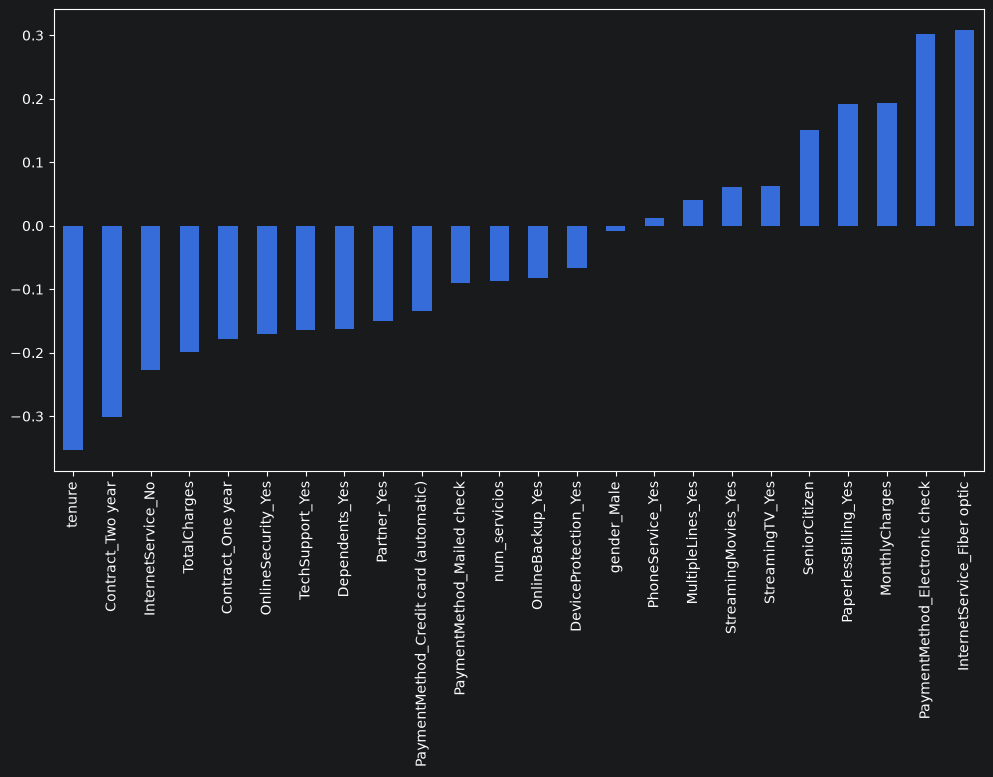

In [16]:
plt.figure(figsize=(12,6))
df.corr()['Churn'].sort_values()[:-1].plot(kind='bar') # Quitamos la propia variable objetivo #

Las variables con más correlación negativa (menos abandono) son tenure (-0,35), el contrato de dos años (-0,30) y no tener internet (-0,23). Las de más correlación positiva (más abandono) son la fibra óptica (0,31), el pago con cheque electrónico (0,30), MonthlyCharges (0,19) y la factura digital (0,19). Esto coincide con lo visto en el notebook 01.

gender_Male (-0,01) y PhoneService_Yes (0,01) casi no tienen correlación con Churn; se podrían eliminar, pero por ahora se dejan.

num_servicios tiene una correlación baja (-0,09) porque su relación con Churn no es una línea recta: en el notebook 01 se ve que el grupo con 0 servicios tiene una tasa menor que el grupo con 1.

In [17]:
# Separar entradas X y objetivo Y #
X = df.drop(columns="Churn")   # lo que el modelo usa para predecir
y = df["Churn"]                # lo que el modelo debe predecir

In [18]:
# Dividimos los datos para entrenar y probar #
# 80% para entrenar y 20% para probar #
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Churn en train:", y_train.mean())
print("Churn en test:", y_test.mean())

Train: (5625, 24)  Test: (1407, 24)
Churn en train: 0.26915555555555554
Churn en test: 0.2523098791755508


In [19]:
# Escalar con MinMaxScaler #
scaler = MinMaxScaler()

# fit_transform aprende los mínimos y máximos SOLO con train #
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)

# test solo se transforma con lo aprendido en train #
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

X_train.describe().loc[["min", "max"]]

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,num_servicios,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [20]:
# Guardamos los archivos #
train = X_train.copy()
train["Churn"] = y_train.values
test = X_test.copy()
test["Churn"] = y_test.values

train.to_csv("../data/processed/train.csv", index=False)
test.to_csv("../data/processed/test.csv", index=False)

joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(list(X.columns), "../models/columnas.pkl")

['../models/columnas.pkl']